## Assignment 2 Learning Strategy: Regularization Experiments on MNIST
### Ananda Auliya Rahma (24/533691/PA/22608)



### 1. Load Data

In [14]:
import numpy as np
import keras

(X_train, y_train_raw), (X_test, y_test_raw) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')
X_train /= 255
X_test /= 255

y_train = keras.utils.to_categorical(y_train_raw, 10)
y_test = keras.utils.to_categorical(y_test_raw, 10)

print('X_train', X_train.shape)
print('X_test', X_test.shape)

X_train (60000, 28, 28, 1)
X_test (10000, 28, 28, 1)


### 2. Baseline Model

In [15]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history = model1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model1.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8893 - loss: 0.4048 - val_acc: 0.9325 - val_loss: 0.2344
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9437 - loss: 0.1992 - val_acc: 0.9499 - val_loss: 0.1644
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9571 - loss: 0.1502 - val_acc: 0.9602 - val_loss: 0.1351
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9654 - loss: 0.1200 - val_acc: 0.9616 - val_loss: 0.1281
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9704 - loss: 0.1010 - val_acc: 0.9673 - val_loss: 0.1076
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9744 - loss: 0.0863 - val_acc: 0.9701 - val_loss: 0.1006
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9779 - loss: 0.0751 - val_acc: 0.9691 - val_loss: 0.0994
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9805 - loss: 0.0658 - val_acc: 0.9740 - val_loss: 0.0860
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

In [16]:
loss, accuracy = model1.evaluate(X_test, y_test)
print('Akurasi Testing Baseline:', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9758 - loss: 0.0831
Akurasi Testing Baseline: 0.9757999777793884


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9758 - loss: 0.0831
Akurasi Testing Baseline: 0.9757999777793884


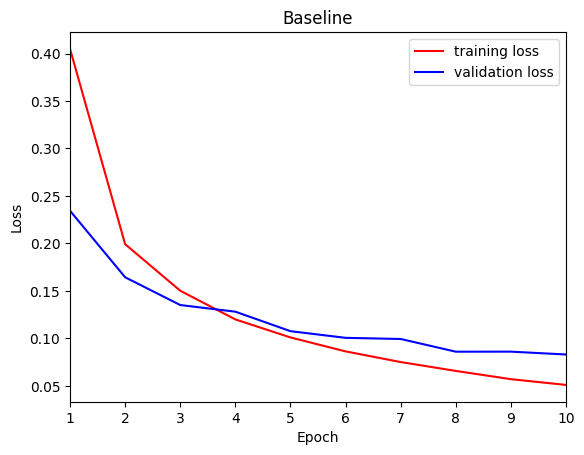

In [32]:
import matplotlib.pyplot as plt

loss, acc = model1.evaluate(X_test, y_test)

print('Akurasi Testing Baseline:', acc)

plt.plot(range(1, len(history.history['loss']) + 1),
         history.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history.history['val_loss']) + 1),
         history.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, 11))
plt.xlim(1, 10)

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline')

plt.show()

### 3. Experiment A. L1 Regularization

In [17]:
from keras.regularizers import l1

L1_RATE = 0.0001

model_l1 = Sequential()
model_l1.add(Flatten())
model_l1.add(Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE)))
model_l1.add(Dense(10, activation='softmax', kernel_regularizer=l1(L1_RATE)))
model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history_l1 = model_l1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model_l1.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8902 - loss: 0.5393 - val_acc: 0.9376 - val_loss: 0.3486
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9406 - loss: 0.3305 - val_acc: 0.9528 - val_loss: 0.2887
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9527 - loss: 0.2817 - val_acc: 0.9587 - val_loss: 0.2570
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9595 - loss: 0.2546 - val_acc: 0.9621 - val_loss: 0.2424
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9639 - loss: 0.2352 - val_acc: 0.9654 - val_loss: 0.2264
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9678 - loss: 0.2219 - val_acc: 0.9680 - val_loss: 0.2151
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9700 - loss: 0.2121 - val_acc: 0.9702 - val_loss: 0.2056
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9715 - loss: 0.2040 - val_acc: 0.9708 - val_loss: 0.2009
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9720 - loss: 0.1948
Akurasi Testing L1: 0.972000002861023


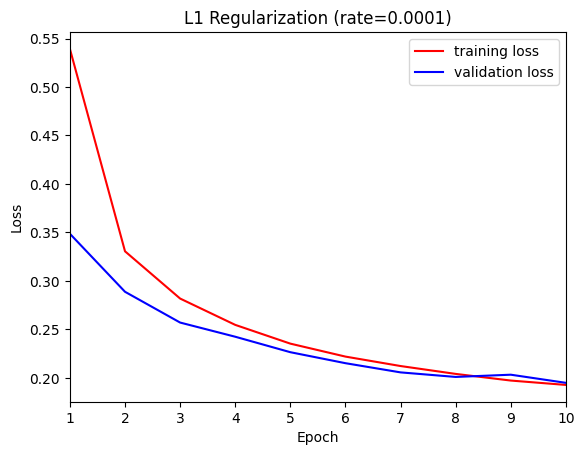

In [18]:
import matplotlib.pyplot as plt

loss, acc = model_l1.evaluate(X_test, y_test)
print('Akurasi Testing L1:', acc)

plt.plot(range(1, len(history_l1.history['loss']) + 1),
         history_l1.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history_l1.history['val_loss']) + 1),
         history_l1.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, 11))
plt.xlim(1, 10)
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'L1 Regularization (rate={L1_RATE})')
plt.show()

### 3. Experiment B. L2 Regularization

In [19]:
from keras.regularizers import l2

L2_RATE = 0.001

model_l2 = Sequential()
model_l2.add(Flatten())
model_l2.add(Dense(64, activation='relu', kernel_regularizer=l2(L2_RATE)))
model_l2.add(Dense(10, activation='softmax', kernel_regularizer=l2(L2_RATE)))
model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history_l2 = model_l2.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model_l2.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8913 - loss: 0.5108 - val_acc: 0.9316 - val_loss: 0.3409
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9382 - loss: 0.3268 - val_acc: 0.9461 - val_loss: 0.2915
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9488 - loss: 0.2907 - val_acc: 0.9546 - val_loss: 0.2743
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9548 - loss: 0.2737 - val_acc: 0.9583 - val_loss: 0.2619
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9585 - loss: 0.2640 - val_acc: 0.9644 - val_loss: 0.2499
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9612 - loss: 0.2570 - val_acc: 0.9619 - val_loss: 0.2535
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9635 - loss: 0.2530 - val_acc: 0.9671 - val_loss: 0.2446
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9645 - loss: 0.2497 - val_acc: 0.9666 - val_loss: 0.2443
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9674 - loss: 0.2439
Akurasi Testing L2: 0.9674000144004822


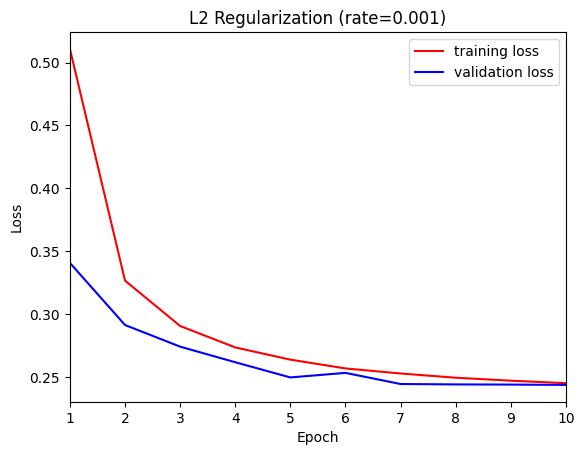

In [20]:
loss, acc = model_l2.evaluate(X_test, y_test)

print('Akurasi Testing L2:', acc)

plt.plot(range(1, len(history_l2.history['loss']) + 1),
         history_l2.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history_l2.history['val_loss']) + 1),
         history_l2.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, 11))
plt.xlim(1, 10)

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'L2 Regularization (rate={L2_RATE})')

plt.show()

### 5. Experiment C. Dropout

In [21]:
from keras.layers import Dropout

DROPOUT_RATE = 0.3

model_do = Sequential()
model_do.add(Flatten())
model_do.add(Dense(64, activation='relu'))
model_do.add(Dropout(DROPOUT_RATE))
model_do.add(Dense(10, activation='softmax'))
model_do.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history_do = model_do.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model_do.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8490 - loss: 0.5155 - val_acc: 0.9356 - val_loss: 0.2264
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9216 - loss: 0.2677 - val_acc: 0.9502 - val_loss: 0.1664
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9350 - loss: 0.2203 - val_acc: 0.9543 - val_loss: 0.1486
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9415 - loss: 0.1958 - val_acc: 0.9619 - val_loss: 0.1269
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9469 - loss: 0.1767 - val_acc: 0.9645 - val_loss: 0.1172
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9505 - loss: 0.1629 - val_acc: 0.9668 - val_loss: 0.1112
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9533 - loss: 0.1555 - val_acc: 0.9677 - val_loss: 0.1080
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9553 - loss: 0.1470 - val_acc: 0.9687 - val_loss: 0.1012
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9692 - loss: 0.0982
Akurasi Testing Dropout: 0.9692000150680542


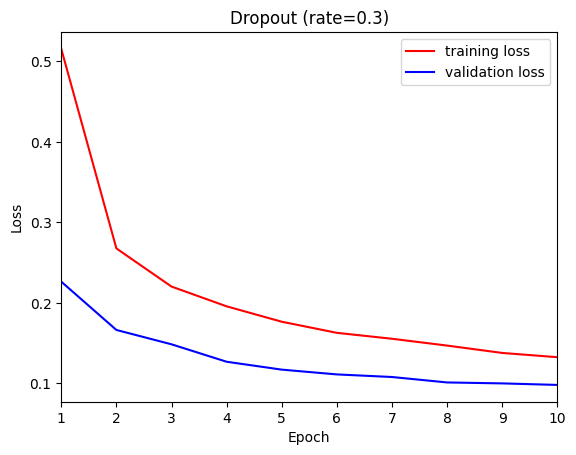

In [22]:
loss, acc = model_do.evaluate(X_test, y_test)

print('Akurasi Testing Dropout:', acc)

plt.plot(range(1, len(history_do.history['loss']) + 1),
         history_do.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history_do.history['val_loss']) + 1),
         history_do.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, 11))
plt.xlim(1, 10)

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Dropout (rate={DROPOUT_RATE})')

plt.show()

### 6. Experiment D. Early Stopping

In [23]:
from keras.callbacks import EarlyStopping

model_es = Sequential()
model_es.add(Flatten())
model_es.add(Dense(64, activation='relu'))
model_es.add(Dense(10, activation='softmax'))
model_es.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

es_cb = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history_es = model_es.fit(X_train, y_train, epochs=50, batch_size=100,
                           validation_data=(X_test, y_test), callbacks=[es_cb])
model_es.summary()

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8952 - loss: 0.3836 - val_acc: 0.9422 - val_loss: 0.2026
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9496 - loss: 0.1752 - val_acc: 0.9551 - val_loss: 0.1500
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9618 - loss: 0.1320 - val_acc: 0.9634 - val_loss: 0.1200
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9691 - loss: 0.1077 - val_acc: 0.9667 - val_loss: 0.1102
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9740 - loss: 0.0902 - val_acc: 0.9686 - val_loss: 0.1020
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9766 - loss: 0.0790 - val_acc: 0.9703 - val_loss: 0.0970
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9799 - loss: 0.0689 - val_acc: 0.9732 - val_loss: 0.0885
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9821 - loss: 0.0600 - val_acc: 0.9717 - val_loss: 0.0904
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9758 - loss: 0.0810
Akurasi Testing Early Stopping: 0.9757999777793884
Jumlah epoch yang benar-benar berjalan: 14


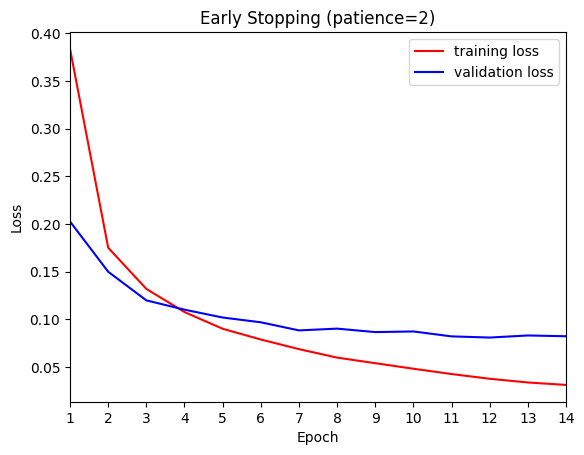

In [24]:
loss, acc = model_es.evaluate(X_test, y_test)

print('Akurasi Testing Early Stopping:', acc)

print('Jumlah epoch yang benar-benar berjalan:', len(history_es.history['loss']))

plt.plot(range(1, len(history_es.history['loss']) + 1),
         history_es.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history_es.history['val_loss']) + 1),
         history_es.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, len(history_es.history['loss']) + 1))
plt.xlim(1, len(history_es.history['loss']))

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Early Stopping (patience=2)')

plt.show()

### 7. Experiment E. L1 Regularization + Dropout

In [30]:
model_l1do = Sequential()
model_l1do.add(Flatten())
model_l1do.add(Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE)))
model_l1do.add(Dropout(DROPOUT_RATE))
model_l1do.add(Dense(10, activation='softmax', kernel_regularizer=l1(L1_RATE)))
model_l1do.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history_l1do = model_l1do.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model_l1do.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8559 - loss: 0.6417 - val_acc: 0.9324 - val_loss: 0.3703
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9178 - loss: 0.4162 - val_acc: 0.9450 - val_loss: 0.3135
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9309 - loss: 0.3660 - val_acc: 0.9543 - val_loss: 0.2787
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9386 - loss: 0.3368 - val_acc: 0.9569 - val_loss: 0.2602
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9422 - loss: 0.3197 - val_acc: 0.9613 - val_loss: 0.2473
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9451 - loss: 0.3067 - val_acc: 0.9644 - val_loss: 0.2403
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9482 - loss: 0.2984 - val_acc: 0.9648 - val_loss: 0.2328
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9488 - loss: 0.2931 - val_acc: 0.9678 - val_loss: 0.2250
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9681 - loss: 0.2250
Akurasi Testing L1+Dropout: 0.9681000113487244


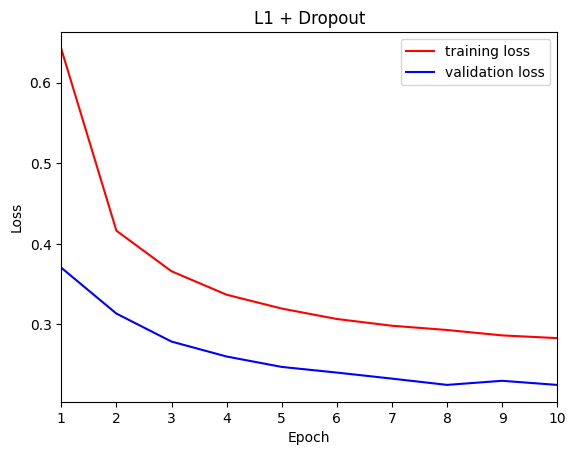

In [31]:
loss, acc = model_l1do.evaluate(X_test, y_test)

print('Akurasi Testing L1+Dropout:', acc)

plt.plot(range(1, len(history_l1do.history['loss']) + 1),
         history_l1do.history['loss'], 'r', label='training loss')

plt.plot(range(1, len(history_l1do.history['val_loss']) + 1),
         history_l1do.history['val_loss'], 'b', label='validation loss')

plt.xticks(range(1, 11))
plt.xlim(1, 10)

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('L1 + Dropout')

plt.show()